# The champion pipeline, stage by stage

**What each stage does, what it adds to the score, and what it costs in seconds.**

This notebook takes **one single run** of our best ordering pipeline on the fly
connectome and opens it up. For every stage you get the same four answers:

| question | answered by |
|---|---|
| *What is this stage?* | a short plain-language description |
| *How does it work?* | the one idea that makes it correct |
| *What does it add?* | percentage points, read from the run's own log |
| *What does it cost?* | seconds, read from the same log |

**Nothing here is recomputed or estimated.** Every number is read from a file
written by an experiment that actually ran. The notebook itself does no
optimisation: it loads a few JSON files and draws pictures. It runs in a few
seconds on a laptop, with no GPU and without the graph datasets.

---

## 1. The problem in one picture

We are given a **brain wiring diagram** (a connectome): neurons are nodes, synaptic
connections are directed weighted edges.

**Task.** Place every neuron at a position on a line. An edge $u \rightarrow v$ is
called **feedforward** if $u$ sits before $v$, and **feedback** otherwise.

$$\text{edge } (u,v) \text{ is feedforward} \iff \mathrm{pos}(u) < \mathrm{pos}(v)$$

**Goal.** Choose the ordering that makes the **total weight of feedforward edges**
as large as possible. This is the *Maximum Feedforward Arc Set* problem — the
mirror image of the classical Minimum Feedback Arc Set problem, and NP-hard.

**The score** we report throughout is

$$\text{score} \;=\; \frac{\text{feedforward weight}}{\text{total edge weight}} \times 100\%$$

**Why anyone cares.** Whatever weight is left over is **feedback that no ordering
can remove**. It is a structural property of the wiring itself, not of our
algorithm — which is what makes it interesting for a thesis about feedback in
brains.

### The three datasets

| dataset | what it is | nodes | edges |
|---|---|---|---|
| `connectome` | FlyWire — the whole fly brain | 136,648 | 5,657,719 |
| `microns` | MICrONS minnie65 — a piece of mouse visual cortex | 67,534 | 10,436,569 |
| `mouse` | a small mouse connectivity table | 148 | 583 |

`connectome` is the dataset the project is *about*; the other two are there to
check that a result is not an accident of one graph.

---

## 2. Setup and configuration

Everything the notebook depends on is declared here — file paths, colours, the
reference score. No number appears anywhere below that was not either read from
one of these files or computed from them in front of you.

In [1]:
"""Configuration and helpers. Run this cell first."""
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np

# ── Locate the repository root (the folder holding `results/` and `experiments/`)
def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    """Walk upwards from `start` until a folder with results/ and experiments/ is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "results").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from %s" % start)


ROOT = find_repo_root(pathlib.Path.cwd())

CONFIG = {
    # ── The run we open up. One run per dataset, chosen as the most authoritative
    #    record available (role `confirm` > `verify` > `implement`).
    "trace": {
        "connectome": "results/20260816T221113Z-H52-connectome-s42-confirm-8b352c.json",
        "microns":    "results/20260816T211725Z-H52-microns-s42-verify-c1e323.json",
        "mouse":      "results/20260816T211632Z-H52-mouse-s42-confirm-b458f1.json",
    },
    # ── The microns run WITH stage 5 enabled (it is switched off in the trace above;
    #    section 8 explains why).
    "microns_stage5_on": "results/20260816T201538Z-H52-microns-s42-implement-c1e323.json",

    # ── Ablation: the same pipeline run with the gradient phase resized.
    "epoch_grid": {
        "connectome": "experiments/outputs/proto_S01_connectome.json",
        "microns":    "experiments/outputs/proto_P07.json",
    },

    # ── The history of the project, as (variant id, plain-language label).
    "history": [
        ("baseline_passthrough", "Rocket from a random start"),
        ("H02",                  "+ greedy warm start"),
        ("H30",                  "+ node sift"),
        ("H35",                  "+ under-relaxation"),
        ("H36",                  "+ SCC block moves"),
        ("H42",                  "+ re-allocated budget"),
        ("H52",                  "+ pair moves (not promoted)"),
    ],

    # ── A published near-optimal ordering for `connectome`, used ONLY as a yardstick.
    #    It never enters any algorithm.
    "reference_pct": 84.6147,
    "reference_note": "best FlyWire leaderboard submission on file, scored by the frozen "
                      "oracle; its method could not be retrieved (NOT the 84.6125% of "
                      "Vahidi 2025)",

    # ── Plot settings.
    "dpi": 120,
    "figdir": "notebooks/outputs",
    # Categorical palette, slots 1-5 of the project's validated default, used in
    # the documented order (worst adjacent colour-blind separation dE 9.1).
    "stage_colors": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"],
    "ink": "#0b0b0b",       # primary text
    "ink_soft": "#52514e",  # secondary text
    "grid": "#d9d8d4",      # recessive gridlines
}

FIGDIR = ROOT / CONFIG["figdir"]
FIGDIR.mkdir(parents=True, exist_ok=True)


def load_json(relative_path: str) -> dict:
    """Read a JSON artifact from the repository, by path relative to the root."""
    return json.loads((ROOT / relative_path).read_text())


def save_fig(fig, name: str) -> None:
    """Save a figure to notebooks/outputs/ and report where it went."""
    path = FIGDIR / name
    fig.savefig(path, dpi=CONFIG["dpi"], bbox_inches="tight", facecolor="white")
    print("saved:", path.relative_to(ROOT))


def style_axes(ax, *, ygrid: bool = True) -> None:
    """Apply the project's chart style: recessive grid, no top/right spines."""
    ax.set_axisbelow(True)
    if ygrid:
        ax.grid(axis="y", color=CONFIG["grid"], linewidth=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(CONFIG["grid"])
    ax.tick_params(colors=CONFIG["ink_soft"], labelsize=9)


plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.titlecolor": CONFIG["ink"],
    "axes.labelcolor": CONFIG["ink_soft"],
    "font.size": 10,
    "legend.frameon": False,
})

print("repository root:", ROOT)
print("figures will be written to:", FIGDIR.relative_to(ROOT))

repository root: /Users/abed359/IdeaProjects/university/mfas_autoresearch/nn_backward_connections
figures will be written to: notebooks/outputs


---

## 3. Where the numbers come from

Three rules govern every number in this notebook. They are project invariants, not
choices made for this document.

**1. One scorer, frozen.** A single function computes the feedforward weight. Its
source file is locked: read-only on disk, hash-checked before every run, and a test
asserts a known answer.

The algorithms *may* consult that scorer, but only in one restricted way, called
**best-by-oracle**: they hand it a whole candidate ordering they have already built,
and keep whichever candidate scores highest. The scorer never enters the choice of
an individual move — every move is selected from the input edge weights and the
current order alone. And no algorithm ever reads the reference solution;
that is used for measurement only. This is what stops a variant from quietly
optimising the metric instead of solving the problem.

**2. Every number lives in a file.** Each run writes a JSON record: the score, the
seed, the wall-clock, the git commit, the GPU, and — since a later fix — a
per-stage breakdown. This notebook reads those records. It cannot invent a number,
because it never computes one from the graph.

**3. This pipeline is deterministic — and that cuts both ways.** It never draws a
random number: the starting order is built from the graph, and every refinement move
is an exact deterministic computation. Accordingly the five confirm runs at five
different seeds return the **same score to every decimal place** (standard deviation
exactly 0.0).

What that buys: a single run is not one sample from a spread, so quoting one run's
per-stage breakdown is legitimate rather than cherry-picking.

What it does **not** buy — and this matters later: because the algorithm ignores the
seed by construction, those five seeds are five repetitions of *one computation*.
They demonstrate that the machine reproduces itself; they say **nothing** about
robustness to a different graph, a different setting, or a different machine. (The
same variant scores 83.9101% on an Apple GPU and 83.9135% on the NVIDIA one — see
section 10.) Section 11 leans on exactly this point.

*(A precision note: what the committed records prove is identical **scores**.
Identity of the orderings themselves was checked separately for earlier stages of
this pipeline and recorded in the project log; the per-seed ordering vectors are not
committed, so this notebook does not re-derive it.)*

The cell below prints the identity card of the run we are about to dissect.

In [2]:
"""Load the run we will open up, and show its provenance."""
run = load_json(CONFIG["trace"]["connectome"])
attrs = run["variant_attrs"]          # the per-stage breakdown

print("RUN IDENTITY CARD")
print("-" * 62)
for key in ["exp_id", "algo", "dataset", "seed", "role", "timestamp", "git_commit"]:
    print(f"  {key:14s} {run[key]}")
print(f"  {'device':14s} {run['env']['gpu']}  (torch {run['env']['jax_or_torch']})")
print()
print(f"  final score    {run['score']:,.0f} of {run['total_weight']:,.0f} total edge weight")
print(f"  final pct      {run['pct']:.5f} %")
print(f"  wall clock     {run['wall_clock_s']:.1f} s")
print(f"  gradient steps {run['total_grad_steps']:,}")
print()
print("Stage-level keys recorded inside this run:")
print("  " + ", ".join(sorted(k for k in attrs if k.endswith(("_pct", "_time_s")))))

RUN IDENTITY CARD
--------------------------------------------------------------
  exp_id         20260816T221113Z-H52-connectome-s42-confirm-8b352c
  algo           H52
  dataset        connectome
  seed           42
  role           confirm
  timestamp      2026-08-16T22:41:43Z
  git_commit     5734d23dc5ec86f77f329a8ac38a855aece4900d+dirty
  device         NVIDIA GeForce RTX 4060 Laptop GPU  (torch torch-2.8.0+cu128)

  final score    35,279,554 of 41,912,141 total edge weight
  final pct      84.17502 %
  wall clock     1818.7 s
  gradient steps 20,000

Stage-level keys recorded inside this run:
  alt_best_pct, alt_time_s, pair_best_pct, pair_time_s, pure_best_pct, refined_best_pct, sift_best_pct, sift_time_s


---

## 4. The pipeline: five stages

The pipeline is a chain. Each stage receives an ordering and returns an ordering
that is **at least as good** — a stage is only allowed to hand on its result if the
frozen scorer confirms it did not make things worse.

```
   stage 1          stage 2          stage 3          stage 4          stage 5
  ┌────────┐      ┌─────────┐      ┌────────┐      ┌──────────┐     ┌─────────┐
  │ greedy │─────▶│ Rocket  │─────▶│  sift  │─────▶│ SCC block│────▶│  pair   │
  │  peel  │      │gradient │      │ 1 node │      │ + sift   │     │ moves   │
  └────────┘      └─────────┘      └────────┘      └──────────┘     └─────────┘
   build an        smooth it        move one        reorder whole    move two
   ordering        with Adam        node at a       blocks at        nodes that
   from scratch                     time            once             only help
                                                                     together
```

Stages 1–4 are the **registered champion** of the project. Stage 5 was measured and
works, but was **not promoted** — section 8 explains exactly why, because that
refusal is itself a result worth showing.

The next cell reads the score and the time at each of these checkpoints out of the
run record.

In [3]:
"""Reconstruct the stage-by-stage chain for the connectome run."""
grid_conn = load_json(CONFIG["epoch_grid"]["connectome"])

# The production run record logs stages 3-5 individually, but reports stages 1-2 only
# as part of the total. The epoch-sizing artifact (same machine, same configuration,
# idle) measured those two separately, so we take the SPLIT from there and check that
# it is consistent with the total.
shipped_arm = next(a for a in grid_conn["arms"] if a["epochs"] == run["total_grad_steps"])

# Stages 3-5: measured inside THIS run.
t_sift   = attrs["sift_time_s"]
t_alt    = attrs["alt_time_s"]
t_pair   = attrs["pair_time_s"]

# Stages 1-2: this run records them only in aggregate, so take the total from THIS run
# and the split between them from the sizing artifact. The split is therefore
# approximate (the two runs differ by ~9 s over stages 1-2); the combined figure is exact.
t_stage12 = (run["runtime_guard"]["variant_wall_s"] - t_sift - t_alt - t_pair)
t_greedy_ref = grid_conn["t_greedy_fas_s"]
t_rocket_ref = shipped_arm["t_rocket_s"]
split = t_greedy_ref / (t_greedy_ref + t_rocket_ref)
t_greedy, t_rocket = t_stage12 * split, t_stage12 * (1 - split)

# Score after each stage, all read from the artifacts:
pct_greedy = grid_conn["arms"][0]["pure_pct"]   # the 0-epoch arm IS the greedy order alone
pct_rocket = attrs["pure_best_pct"]
pct_sift   = attrs["sift_best_pct"]
pct_alt    = attrs["alt_best_pct"]
pct_pair   = attrs["pair_best_pct"]

STAGES = [
    # (name, short name for axis ticks, score after the stage, seconds)
    ("1. Greedy peel",       "1. Greedy\npeel",       pct_greedy, t_greedy),
    ("2. Rocket (gradient)", "2. Rocket\n(gradient)", pct_rocket, t_rocket),
    ("3. Node sift",         "3. Node\nsift",         pct_sift,   t_sift),
    ("4. SCC block + sift",  "4. SCC block\n+ sift",  pct_alt,    t_alt),
    ("5. Pair moves",        "5. Pair\nmoves",        pct_pair,   t_pair),
]

# Stage 1 BUILDS the first ordering, so it has no "gain over the previous stage" —
# it is the baseline the other four are measured against. Its gain is left undefined
# rather than measured from zero, which would be meaningless.
rows, prev = [], None
for name, short, pct_after, seconds in STAGES:
    gain = None if prev is None else pct_after - prev
    rows.append({
        "stage": name,
        "short": short,
        "score_after_pct": pct_after,
        "gain_pp": gain,
        "seconds": seconds,
        "pp_per_min": None if (gain is None or seconds <= 0) else gain / (seconds / 60.0),
    })
    prev = pct_after

overhead = run["wall_clock_s"] - run["runtime_guard"]["variant_wall_s"]
gain_rows = rows[1:]                      # the four stages that improve an ordering
total_gain = sum(r["gain_pp"] for r in gain_rows)

hdr = f"{'stage':24s} {'score after':>12s} {'adds':>10s} {'costs':>10s} {'rate':>13s}"
print(hdr)
print("-" * len(hdr))
for r in rows:
    gain_s = "  (start)" if r["gain_pp"] is None else f"{r['gain_pp']:+9.5f}"
    rate_s = "         --" if r["pp_per_min"] is None else f"{r['pp_per_min']:10.4f}"
    print(f"{r['stage']:24s} {r['score_after_pct']:11.5f}% {gain_s:>10s} "
          f"{r['seconds']:9.1f}s {rate_s} pp/min")
print("-" * len(hdr))
print(f"{'harness overhead':24s} {'':12s} {'':10s} {overhead:9.1f}s"
      "   (init, re-scoring, saving -- outside every stage)")
print(f"{'TOTAL (run record)':24s} {run['pct']:11.5f}% {'':10s} {run['wall_clock_s']:9.1f}s")
print(f"\nTotal gain above the greedy starting ordering: {total_gain:.5f} pp")
print(f"Stages 1+2 measured together in this run: {t_stage12:.1f} s; the split between "
      f"them\n  ({t_greedy:.0f} s / {t_rocket:.0f} s) is prorated from the sizing artifact "
      "and is approximate.")

stage                     score after       adds      costs          rate
-------------------------------------------------------------------------
1. Greedy peel              68.91343%    (start)      16.6s          -- pp/min
2. Rocket (gradient)        82.92970%  +14.01627     385.3s     2.1829 pp/min
3. Node sift                83.91352%   +0.98382     121.3s     0.4865 pp/min
4. SCC block + sift         84.15410%   +0.24058     630.3s     0.0229 pp/min
5. Pair moves               84.17502%   +0.02093     646.4s     0.0019 pp/min
-------------------------------------------------------------------------
harness overhead                                      18.7s   (init, re-scoring, saving -- outside every stage)
TOTAL (run record)          84.17502%               1818.7s

Total gain above the greedy starting ordering: 15.26159 pp
Stages 1+2 measured together in this run: 401.9 s; the split between them
  (17 s / 385 s) is prorated from the sizing artifact and is approximate.


### How to read that table

* **`score after`** — the exact feedforward percentage once this stage has finished.
* **`adds`** — how much this stage improved the ordering *given everything before
  it*. These are percentage points (pp) of the total edge weight.
* **`costs`** — seconds of wall clock on the machine that ran it (an NVIDIA
  RTX 4060 laptop GPU).
* **`rate`** — percentage points bought per minute. This is the column that shows
  the shape of the problem.

Two things jump out immediately, and both are discussed below:

1. **Stage 2 looks enormous (+14 pp) but section 7 shows it is worth far less than
   that** — because stage 3 would have found most of it anyway.
2. **The rate collapses by a factor of ~250** between stage 3 and stage 5. Later
   stages are not slightly worse investments; they are two orders of magnitude worse.

---

## 5. Two pictures of the same run

**Figure 1 (waterfall)** answers *"where does the final score come from?"*
Each bar is one stage's contribution, stacked onto the running total.

**Figure 2 (trajectory)** answers *"when during the run was the score actually
earned?"* The x-axis is elapsed seconds, so a steep segment is a productive
minute and a flat one is an expensive minute.

saved: notebooks/outputs/champion_fig1_waterfall.png


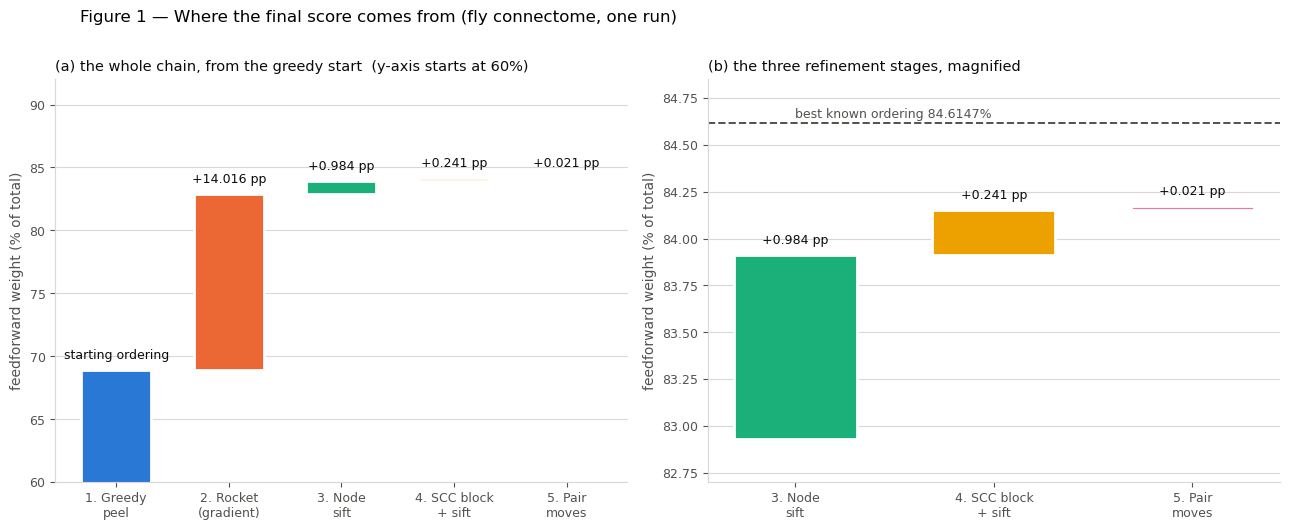

In [4]:
"""Figure 1 — waterfall: where the final score comes from.

Two panels, because the increments span three orders of magnitude: stage 2 adds
14 pp and stage 5 adds 0.02 pp, which cannot share one readable y-axis. Panel (b)
is the same data magnified, NOT a different measurement.
"""
def draw_waterfall(ax, only_from=0):
    """Draw the stage waterfall; `only_from` skips the earlier (huge) stages."""
    for i, r in enumerate(rows):
        if i < only_from:
            continue
        if r["gain_pp"] is None:                   # stage 1 builds the first ordering
            bottom, height, note = 0.0, r["score_after_pct"], "starting ordering"
        else:                                      # stages 2-5 are increments on top
            bottom, height = rows[i - 1]["score_after_pct"], r["gain_pp"]
            note = f"+{r['gain_pp']:.3f} pp"
        ax.bar(i, height, bottom=bottom, width=0.62,
               color=CONFIG["stage_colors"][i], edgecolor="white", linewidth=2.0)
        span = ax.get_ylim()[1] - ax.get_ylim()[0]
        ax.text(i, bottom + height + span * 0.02, note, ha="center", va="bottom",
                fontsize=9, color=CONFIG["ink"])   # direct labels, always visible
    ax.set_xticks(range(only_from, len(rows)))
    ax.set_xticklabels([r["short"] for r in rows[only_from:]], fontsize=9)
    style_axes(ax)


fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.0, 5.2))

axA.set_ylim(60, 92)
draw_waterfall(axA, only_from=0)
axA.set_ylabel("feedforward weight (% of total)")
axA.set_title("(a) the whole chain, from the greedy start  (y-axis starts at 60%)",
              loc="left", fontsize=10.5)

axB.set_ylim(82.7, 84.85)
draw_waterfall(axB, only_from=2)
axB.axhline(CONFIG["reference_pct"], color=CONFIG["ink_soft"],
            linestyle="--", linewidth=1.4)
axB.text(2.0, CONFIG["reference_pct"] + 0.03,
         f"best known ordering {CONFIG['reference_pct']}%",
         ha="left", fontsize=9, color=CONFIG["ink_soft"])
axB.set_ylabel("feedforward weight (% of total)")
axB.set_title("(b) the three refinement stages, magnified", loc="left", fontsize=10.5)

fig.suptitle("Figure 1 — Where the final score comes from (fly connectome, one run)",
             x=0.065, ha="left", fontsize=12, y=1.01)
fig.tight_layout()
save_fig(fig, "champion_fig1_waterfall.png")
plt.show()

saved: notebooks/outputs/champion_fig2_trajectory.png


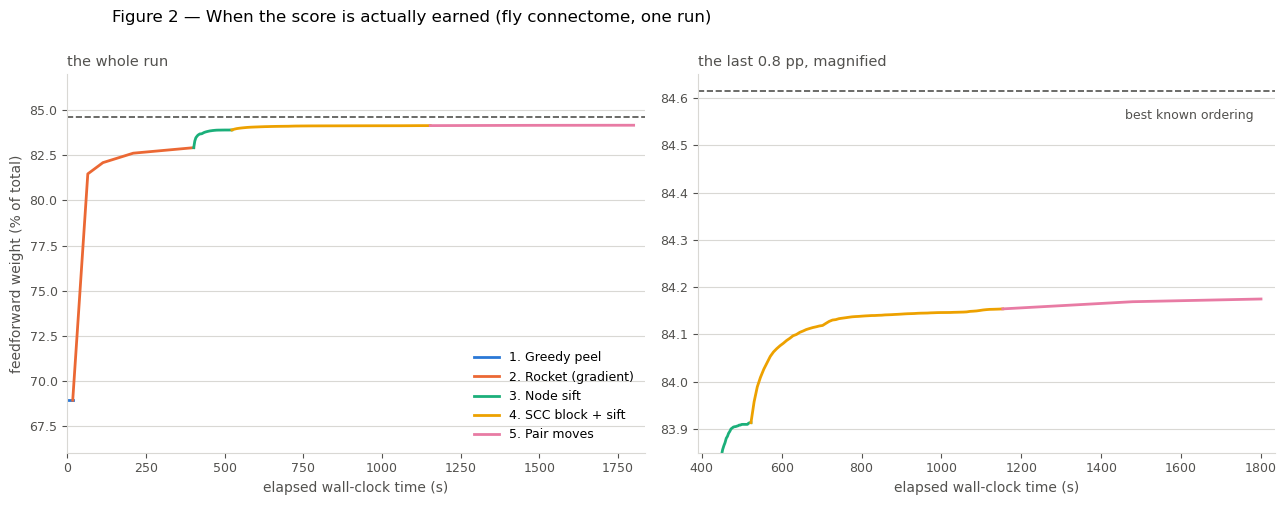

In [5]:
"""Figure 2 — trajectory: score against elapsed wall-clock time."""
# Rebuild the within-stage trajectories from the per-sweep / per-cycle logs.
t, y, seg = [0.0], [pct_greedy], []
cursor = 0.0

# Stage 1: flat (it produces one ordering at the end).
seg.append(("1. Greedy peel", [0.0, t_greedy], [pct_greedy, pct_greedy]))
cursor = t_greedy

# Stage 2: the production run logs only its endpoint, so the SHAPE comes from the
# epoch-sizing probe, which ran the same configuration at 0/2.5k/5k/10k/20k steps.
# Times are rescaled to this run's stage-2 duration; the endpoint matches exactly.
probe = [a for a in grid_conn["arms"] if a["epochs"] <= run["total_grad_steps"]]
scale = t_rocket / max(a["t_rocket_s"] for a in probe)
xs = [cursor + a["t_rocket_s"] * scale for a in probe]
ys = [a["pure_pct"] for a in probe]
assert abs(ys[-1] - pct_rocket) < 1e-9, "the probe's last arm must match this run's stage 2"
seg.append(("2. Rocket (gradient)", xs, ys))
cursor += t_rocket

# stage 3: one point per sweep, best-so-far
xs, ys, running = [cursor], [pct_rocket], pct_rocket
for row in attrs["sift_log"]:
    cursor += row["wall"]
    if row["accepted"]:
        running = max(running, row["candidate_pct"])
    xs.append(cursor); ys.append(running)
seg.append(("3. Node sift", xs, ys))

# stage 4: one point per alternation cycle
base = cursor
xs, ys = [cursor], [pct_sift]
for row in attrs["alt_log"]:
    xs.append(base + row["cum_wall_s"]); ys.append(row["best_pct"])
cursor = base + attrs["alt_log"][-1]["cum_wall_s"]
seg.append(("4. SCC block + sift", xs, ys))

# stage 5: one point per pass
base = cursor
xs, ys = [cursor], [pct_alt]
for row in attrs["pair_log"]:
    xs.append(base + row["cum_wall_s"]); ys.append(row["after_pct"])
cursor = base + attrs["pair_log"][-1]["cum_wall_s"]
seg.append(("5. Pair moves", xs, ys))

fig, (ax_full, ax_zoom) = plt.subplots(
    1, 2, figsize=(13.0, 5.0), gridspec_kw={"width_ratios": [1, 1]})

stage3_starts_at = t_greedy + t_rocket
for ax, title, ylim, xlim in [
    (ax_full, "the whole run", (66, 87), (0, cursor * 1.02)),
    (ax_zoom, "the last 0.8 pp, magnified", (83.85, 84.65),
     (stage3_starts_at * 0.97, cursor * 1.02)),
]:
    for (label, xs_, ys_), color in zip(seg, CONFIG["stage_colors"]):
        ax.plot(xs_, ys_, color=color, linewidth=2.0, label=label,
                solid_joinstyle="round")
    ax.axhline(CONFIG["reference_pct"], color=CONFIG["ink_soft"],
               linestyle="--", linewidth=1.2)
    ax.set_xlabel("elapsed wall-clock time (s)")
    ax.set_ylim(*ylim)
    ax.set_xlim(*xlim)
    ax.set_title(title, loc="left", fontsize=10.5, color=CONFIG["ink_soft"])
    style_axes(ax)

ax_full.set_ylabel("feedforward weight (% of total)")
ax_zoom.text(cursor * 0.99, CONFIG["reference_pct"] - 0.06, "best known ordering",
             ha="right", fontsize=9, color=CONFIG["ink_soft"])
ax_full.legend(loc="lower right", fontsize=9)
fig.suptitle("Figure 2 — When the score is actually earned (fly connectome, one run)",
             x=0.09, ha="left", fontsize=12, y=1.00)
fig.tight_layout()
save_fig(fig, "champion_fig2_trajectory.png")
plt.show()

**Reading figure 2.** The left panel shows the whole run: nearly all of the height
is gained in the first ~9 minutes, and the curve is visually flat afterwards. Note
the shape of the orange stage-2 segment — it is steep at the start and then bends
over. 2,500 gradient steps already reach 81.5%, which is **90% of the gradient
phase's whole contribution for 13% of its time**. The last two thirds of the
gradient budget buy very little, which is exactly what section 8 measures.

The right panel magnifies the top of the run — the region the last two stages work
in, and where the remaining distance to the best known ordering lives. After stage 3
the pipeline spends **21 minutes** climbing about **0.26 pp**, and still finishes
**0.44 pp** short of the reference ordering.

*(Provenance: the production run logs stage 2 only at its endpoint, so the shape of
that segment is taken from the epoch-sizing probe — the same configuration measured
at 0 / 2,500 / 5,000 / 10,000 / 20,000 steps — with times rescaled to this run's
stage-2 duration. Its endpoint matches this run exactly, which the cell asserts.)*

---

## 6. Cost against gain

Figure 3 puts the two columns of the table side by side. The mismatch is the point:
the stages that take the most time are not the stages that produce the score.

saved: notebooks/outputs/champion_fig3_cost_vs_gain.png


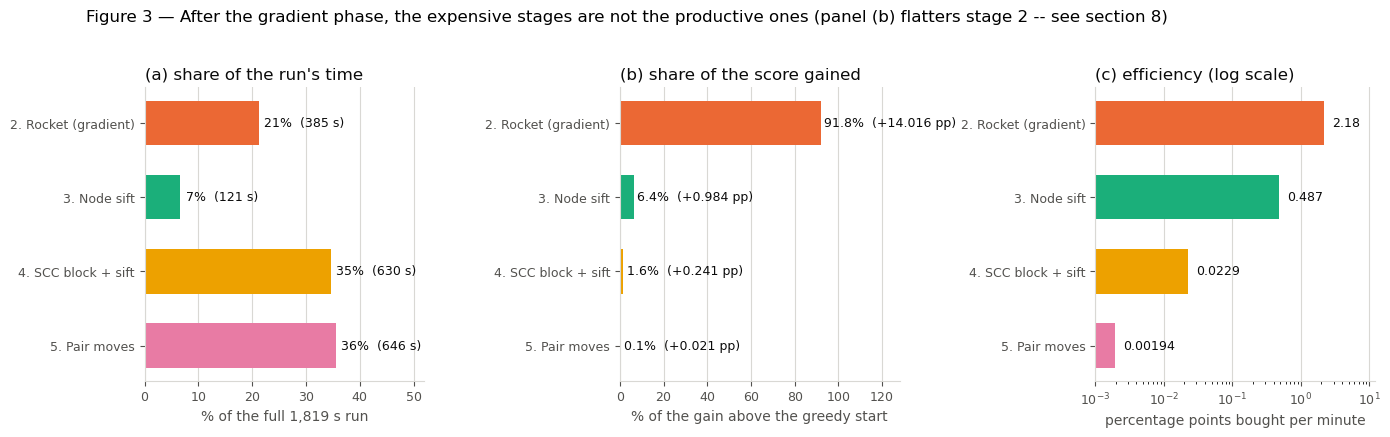


Stage 3 buys 250x more score per minute than stage 5.
Stages 4 and 5 together: 70% of the run's time, 1.7% of the gain above the greedy start.
Panel (b) flatters stage 2 -- section 8 measures what it is really worth.


In [6]:
"""Figure 3 — time spent vs score gained, for the four stages that improve an ordering.

Stage 1 is excluded: it builds the ordering the other four are measured against, so
it has no "gain" on the same scale. Its 17 s are still counted in the time totals.
"""
names = [r["stage"] for r in gain_rows]
gains = np.array([r["gain_pp"] for r in gain_rows])
secs = np.array([r["seconds"] for r in gain_rows])
rates = np.array([r["pp_per_min"] for r in gain_rows])
colors = CONFIG["stage_colors"][1:1 + len(gain_rows)]
total_secs = run["wall_clock_s"]

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))

# (a) share of the whole run's wall clock
share_time = 100 * secs / total_secs
axes[0].barh(range(len(names)), share_time, color=colors, height=0.6)
for i, v in enumerate(share_time):
    axes[0].text(v + 1.0, i, f"{v:.0f}%  ({secs[i]:.0f} s)", va="center",
                 fontsize=9, color=CONFIG["ink"])
axes[0].set_xlim(0, 52)
axes[0].set_title("(a) share of the run's time", loc="left")
axes[0].set_xlabel("% of the full 1,819 s run")

# (b) share of the gain above the greedy starting ordering
share_gain = 100 * gains / gains.sum()
axes[1].barh(range(len(names)), share_gain, color=colors, height=0.6)
for i, v in enumerate(share_gain):
    axes[1].text(v + 1.6, i, f"{v:.1f}%  (+{gains[i]:.3f} pp)", va="center",
                 fontsize=9, color=CONFIG["ink"])
axes[1].set_xlim(0, 128)
axes[1].set_title("(b) share of the score gained", loc="left")
axes[1].set_xlabel("% of the gain above the greedy start")

# (c) efficiency, log scale — the spread is far too large for a linear axis
axes[2].barh(range(len(names)), rates, color=colors, height=0.6)
axes[2].set_xscale("log")
for i, v in enumerate(rates):
    axes[2].text(v * 1.3, i, f"{v:.3g}", va="center", fontsize=9, color=CONFIG["ink"])
axes[2].set_xlim(1e-3, 12)
axes[2].set_title("(c) efficiency (log scale)", loc="left")
axes[2].set_xlabel("percentage points bought per minute")

for ax in axes:
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9.5)
    ax.invert_yaxis()
    style_axes(ax, ygrid=False)
    ax.grid(axis="x", color=CONFIG["grid"], linewidth=0.8)

fig.suptitle("Figure 3 — After the gradient phase, the expensive stages are not the "
             "productive ones (panel (b) flatters stage 2 -- see section 8)",
             x=0.065, ha="left", fontsize=12, y=1.03)
fig.tight_layout()
save_fig(fig, "champion_fig3_cost_vs_gain.png")
plt.show()

print(f"\nStage 3 buys {rates[1] / rates[3]:.0f}x more score per minute than stage 5.")
print(f"Stages 4 and 5 together: {100 * secs[2:].sum() / total_secs:.0f}% of the run's time, "
      f"{100 * gains[2:].sum() / gains.sum():.1f}% of the gain above the greedy start.")
print("Panel (b) flatters stage 2 -- section 8 measures what it is really worth.")

---

## 7. The five stages, one at a time

Everything above was the summary. This section explains what each stage *is*.

### Stage 1 — Greedy peel (build a first ordering)

**What it is.** A classical, very cheap heuristic (Eades–Lin–Smyth, in the weighted
"GreedyAbs" variant) that constructs an ordering from nothing.

**How it works.** Repeat until the graph is empty:

1. If some neuron has no outgoing edges left, it can never point forward — put it at
   the **back** and delete it.
2. If some neuron has no incoming edges left, nothing can point back into it — put it
   at the **front** and delete it.
3. Otherwise take the neuron with the largest *imbalance* (outgoing weight minus
   incoming weight) — the one that most "wants" to point forward — put it at the
   **front** and delete it.

**Why it is a good start.** Steps 1 and 2 are free wins: those placements cannot
cost anything. Step 3 is the only guess, and it guesses in the direction the wiring
already leans.

**What it adds.** It produces an ordering scoring **68.9%**. For scale, a *random*
ordering scores 50% on average — with no information, every edge points forward with
probability one half. So the peel already extracts a large part of the structure.

**What it costs.** ~17 s.

### Stage 2 — Rocket (smooth the ordering with gradient descent)

**What it is.** The algorithm from the paper this project reproduces
(Bader et al., 2025). It is the only stage that uses a GPU.

**How it works.** Instead of an ordering it keeps a **real number** $p_i$ per
neuron — a position on the line. "Is this edge feedforward?" is a yes/no question,
which cannot be differentiated, so it is replaced by a smooth approximation:

$$F(p) \;=\; \sum_{(u,v)} w_{uv} \cdot \sigma\!\big(\beta \,(p_v - p_u)\big)$$

where $\sigma$ is the logistic function. When $p_v \gg p_u$ the term is ≈ the full
weight; when $p_v \ll p_u$ it is ≈ 0. Now Adam can maximise $F$, and $\beta$ is
raised over training so the approximation sharpens towards the true yes/no answer.

**Important.** $F$ is only a stand-in used for *training*. The number we report is
always the exact discrete score, computed afterwards by the frozen scorer.

**What it adds.** 68.9% → **82.93%**, i.e. +14.0 pp *in the chain*. Section 8 shows
that its real contribution to the final answer is far smaller.

**What it costs.** ~394 s and 20,000 gradient steps — the only GPU work in the run.

### Stage 3 — Node sift (move one neuron at a time, to its exactly best place)

**What it is.** The first discrete stage, and the most productive one in the whole
pipeline.

**How it works.** Take one neuron and pretend everything else is frozen. Slide it
along the **entire line** and ask, at each of the possible slots: how much
feedforward weight would I have? This can be computed *exactly and cheaply*,
because moving one neuron only affects its own edges. Put it in the best slot.
Then do that for every neuron.

Two details matter:

* **Full range, not a window.** Earlier work in this project showed that letting a
  neuron move only a few positions recovers essentially nothing — the mistakes are
  long-range. A neuron here can jump across the whole brain.
* **Under-relaxation.** If every neuron jumps to its ideal slot simultaneously, they
  leapfrog each other and the process never settles — it oscillates forever. The fix
  is to move each neuron only **70% of the way** towards its ideal slot after a few
  warm-up passes. That damping breaks the oscillation and the process converges.

**What it adds.** 82.93% → **83.91%**, i.e. **+0.98 pp** — more than every later
stage combined.

**What it costs.** 121 s, and **zero gradient steps**. It is pure CPU arithmetic:
**under 7%** of the run's time for the single largest gain of any stage.

saved: notebooks/outputs/champion_fig4_stage3_sweeps.png


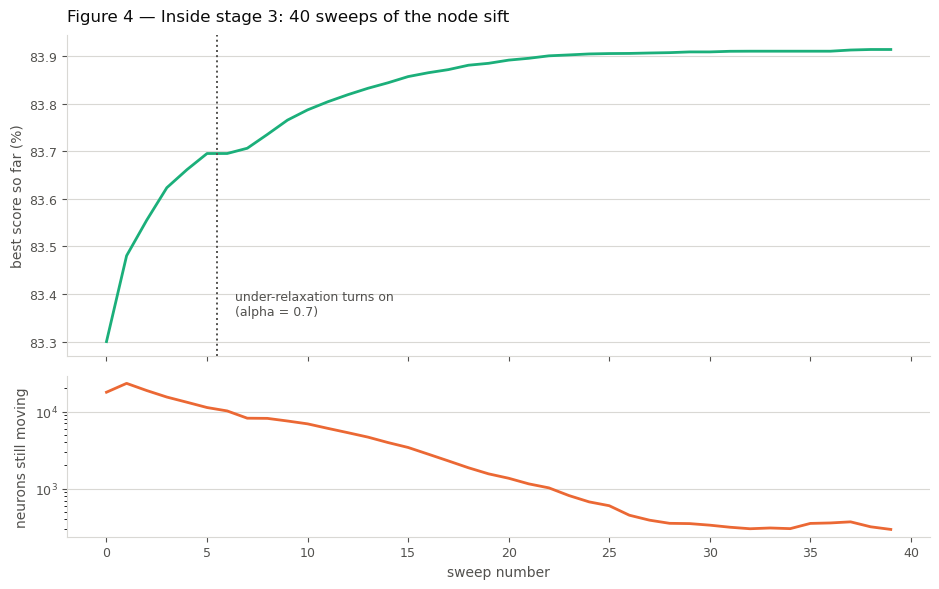

first 6 sweeps:  +0.76539 pp
last 10 sweeps:  +0.00508 pp  in 29.5 s
converged?       False  (40 of 40 sweeps used)
neurons moving:  17,811 on the first sweep -> 295 on the last


In [7]:
"""Figure 4 — inside stage 3: the sift sweeps."""
sweeps = attrs["sift_log"]
best_so_far, running = [], attrs["pure_best_pct"]
for row in sweeps:
    if row["accepted"]:
        running = max(running, row["candidate_pct"])
    best_so_far.append(running)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

x = np.arange(len(sweeps))
ax1.plot(x, best_so_far, color=CONFIG["stage_colors"][2], linewidth=2.0)
switch = attrs["sift_k_full"]
ax1.axvline(switch - 0.5, color=CONFIG["ink_soft"], linestyle=":", linewidth=1.4)
ax1.text(switch + 0.4, best_so_far[0] + 0.05,
         f"under-relaxation turns on\n(alpha = {attrs['sift_alpha']})",
         fontsize=9, color=CONFIG["ink_soft"], va="bottom")
ax1.set_ylabel("best score so far (%)")
ax1.set_title("Figure 4 — Inside stage 3: 40 sweeps of the node sift", loc="left", pad=10)
style_axes(ax1)

movers = [row["n_movers"] for row in sweeps]
ax2.plot(x, movers, color=CONFIG["stage_colors"][1], linewidth=2.0)
ax2.set_yscale("log")
ax2.set_ylabel("neurons still moving")
ax2.set_xlabel("sweep number")
style_axes(ax2)

fig.tight_layout()
save_fig(fig, "champion_fig4_stage3_sweeps.png")
plt.show()

first_six = best_so_far[5] - attrs["pure_best_pct"]
last_ten = best_so_far[-1] - best_so_far[-11]
t_last_ten = sum(r["wall"] for r in sweeps[-10:])
print(f"first 6 sweeps:  +{first_six:.5f} pp")
print(f"last 10 sweeps:  +{last_ten:.5f} pp  in {t_last_ten:.1f} s")
print(f"converged?       {attrs['sift_converged']}  "
      f"({attrs['n_sift_sweeps']} of {attrs['sift_sweeps_requested']} sweeps used)")
print(f"neurons moving:  {movers[0]:,} on the first sweep -> {movers[-1]:,} on the last")

The top panel shows the pattern: almost everything is won in the first handful of
sweeps, then the curve crawls. The bottom panel shows *why* it crawls — the number
of neurons that still want to move falls by nearly two orders of magnitude.

Note the printout: this stage stopped because it **hit its sweep limit**, not
because it finished. But the last ten sweeps bought only ~0.005 pp, so raising the
limit is not where the remaining score is.

### Stage 4 — SCC block moves, alternated with a short sift

**What it is.** A move that relocates **many neurons at once**. Stage 3 can only
move one neuron; if two neurons must move *together* to help, stage 3 is blind to
it.

**How it works — the one idea that makes it correct.**

> **Contiguous-block lemma.** Take any set of neurons occupying a *contiguous
> stretch* of the line. Shuffle them among themselves however you like. Every edge
> with one end **outside** that stretch keeps its direction — because the outside
> end is either before the whole stretch or after the whole stretch.

So a contiguous block is an **independent sub-problem**. Inside a block we can
therefore do something clean:

1. Find the block's **strongly connected components** (groups where you can travel
   from any member to any other and back).
2. Lay the components out in topological order. Every edge *between* components now
   points forward — an edge going back would have merged the two into one component.
3. Keep each component's internal order untouched, so no edge inside a component
   changes.
4. If the block is one single component, cut it in two and recurse into the halves —
   at a cut point that changes from round to round, so later rounds see block
   boundaries earlier ones could not. The halves are smaller graphs, so they usually
   break apart.

Steps 2 and 3 together mean the **block move** can only improve a block or leave it
equal. That part is correct by construction rather than a heuristic gamble, and
`tests/test_refine_scc_recursive.py` (31 tests, three of them on monotonicity) pins
it. The inner sift it alternates with is *not* monotone — it is allowed to go
downhill, and is protected by keeping the best ordering the scorer has ever seen.

**Why it alternates with a short sift.** The block move and the single-node move are
blind to different things. Running them in turn re-opens moves the other had
exhausted; the pair reaches a joint stopping point that neither reaches alone. This
run does 77 such alternations.

**A measured detail worth reporting.** The alternation originally used a long inner
sift. Making the inner sift *cheaper* (2 passes instead of 8) and buying more
alternations with the freed seconds gave a **better** ordering at the **same**
wall-clock. It is the alternation that pays, not the depth of either half.

**What it adds.** 83.91% → **84.15%**, i.e. **+0.24 pp**. Still zero gradient steps.

**What it costs.** 630 s — the single most expensive stage in the run.

saved: notebooks/outputs/champion_fig5_stage4_cycles.png


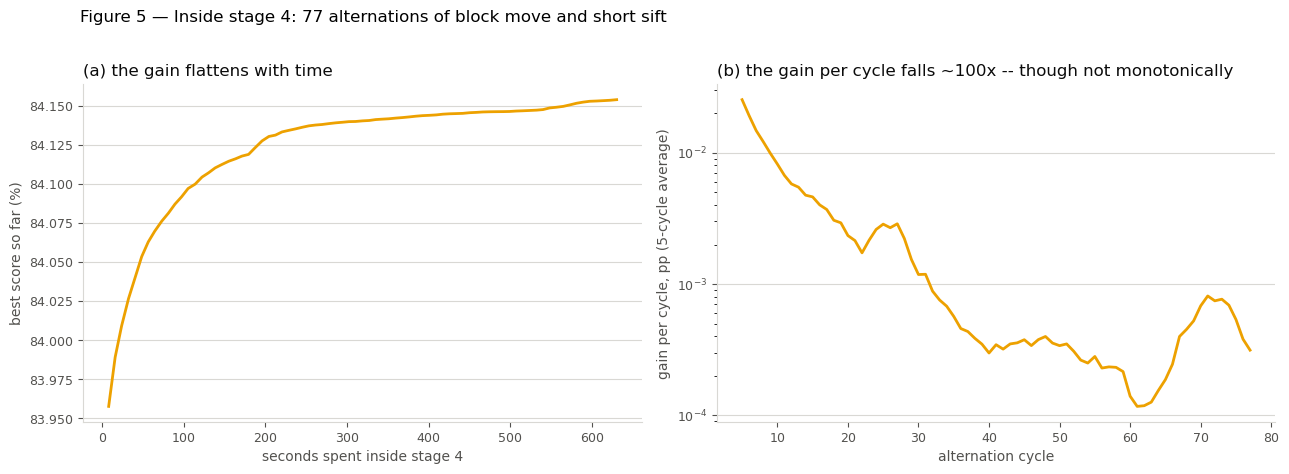

first 38 cycles: +0.22660 pp in 310 s
last  39 cycles: +0.01397 pp in 320 s


In [8]:
"""Figure 5 — inside stage 4: diminishing returns across the alternation cycles."""
alt = attrs["alt_log"]
cyc = np.arange(1, len(alt) + 1)
best = np.array([row["best_pct"] for row in alt])
cum_t = np.array([row["cum_wall_s"] for row in alt])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 4.6))

axL.plot(cum_t, best, color=CONFIG["stage_colors"][3], linewidth=2.0)
axL.set_xlabel("seconds spent inside stage 4")
axL.set_ylabel("best score so far (%)")
axL.set_title("(a) the gain flattens with time", loc="left")
style_axes(axL)

# marginal gain per cycle, smoothed over a small window so the picture is readable
step = np.diff(np.concatenate([[pct_sift], best]))
window = 5
smooth = np.convolve(step, np.ones(window) / window, mode="valid")
axR.plot(cyc[window - 1:], smooth, color=CONFIG["stage_colors"][3], linewidth=2.0)
axR.set_yscale("log")
axR.set_xlabel("alternation cycle")
axR.set_ylabel(f"gain per cycle, pp ({window}-cycle average)")
axR.set_title("(b) the gain per cycle falls ~100x -- though not monotonically", loc="left")
style_axes(axR)

fig.suptitle("Figure 5 — Inside stage 4: 77 alternations of block move and short sift",
             x=0.065, ha="left", fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, "champion_fig5_stage4_cycles.png")
plt.show()

half = len(alt) // 2
print(f"first {half} cycles: +{best[half - 1] - pct_sift:.5f} pp in {cum_t[half - 1]:.0f} s")
print(f"last  {len(alt) - half} cycles: +{best[-1] - best[half - 1]:.5f} pp "
      f"in {cum_t[-1] - cum_t[half - 1]:.0f} s")

### Stage 5 — Pair moves (move two neurons that only help together)

**What it is.** The newest move class, and the one that is **not** part of the
registered champion.

**How it works.** Take a feedback edge $u \rightarrow v$ (so $v$ currently sits
before $u$). Pull **both** endpoints out of the line and re-insert them side by side
at the best available point of the stretch between them — $u$ first, then $v$, which
is what turns the feedback edge into a feedforward one. The contiguous-block lemma
again makes the gain exactly computable.

**Why the champion cannot find these moves.** On the champion's own ordering,
**989 of 3,498** improving pairs have **zero** gain if you move either neuron alone.
Both must move, and both must land together. Stage 3 and stage 4 are blind to that
by construction.

**The finding that matters — how you *apply* the moves dominates.** There are two
ways to use a list of improving moves:

* **Batched:** pick a set of moves that do not overlap each other, apply them all at
  once, then rescan.
* **Sequential:** apply the single best move, then recompute each remaining
  candidate's gain against the ordering it just changed before applying it, and repeat.

Two probes compared these on the same move class. Both point the same way:

| comparison | batched | sequential | ratio |
|---|---|---|---|
| **from the champion's ordering** — one best-possible batch vs six sequential passes | +0.0019 pp (185 moves) | +0.0223 pp (2,511 moves) | 11.6× |
| **from a plain greedy ordering, both iterated to their budget** | +0.6757 pp (40 batch sweeps) | +7.7468 pp (159,671 moves) | 11.5× |

The reason is geometric. A pair move is *wide*: the moves this stage applies span
tens of thousands of the 136,648 positions. Non-overlapping moves of that width
barely fit on the line at all, so the batch could use only **185 of the 3,498**
improving pairs it had found — about 5%. The rest overlapped something already
chosen and were thrown away.

**What this does and does not establish.** Neither comparison is a clean controlled
experiment: in the first, the batched arm gets one round and the sequential arm gets
six; in the second, both iterate but to different budgets. So the two effects —
"one at a time" and "more rounds" — are **not separated**, and the honest statement
is that the *combination* is worth roughly an order of magnitude, not that batching
alone causes it. What makes the finding credible is that two differently-flawed
comparisons, from different starting orderings, land on the same factor.

There is a related trap elsewhere in the project: the **segment** refiner selects a
maximal set of *disjoint* windows per sweep, which is right when a move is a few
positions wide and questionable when it is tens of thousands. (The node sift of
stage 3 is a different shape again — a Jacobi step in which every mover moves at
once, deliberately overlapping, which is precisely why it needs under-relaxation to
settle.)

**What it adds.** 84.154% → **84.175%**, i.e. **+0.021 pp**.

**What it costs.** 646 s — as expensive as stage 4, for a tenth of the gain.

saved: notebooks/outputs/champion_fig6_stage5_pairs.png


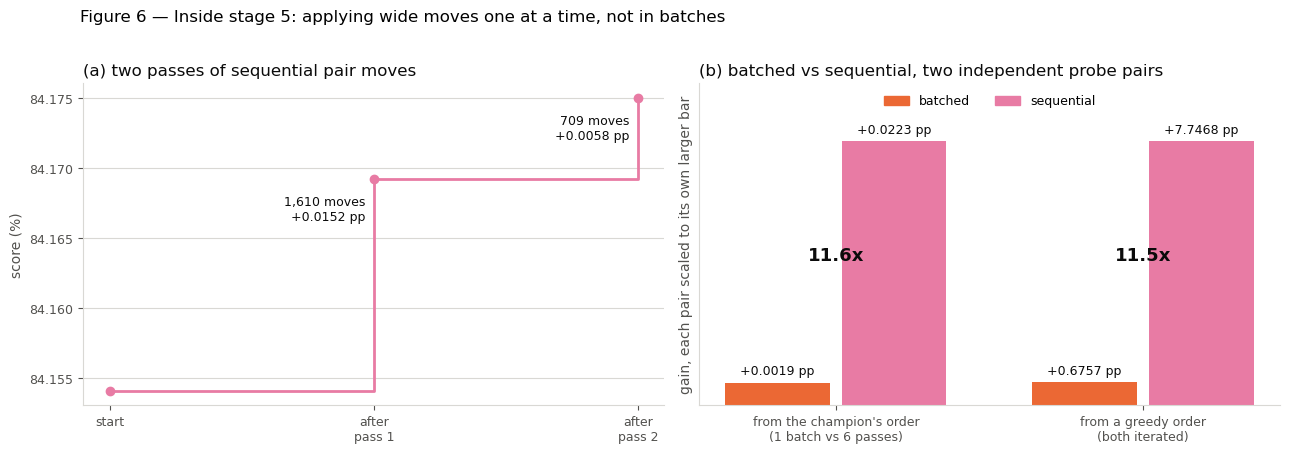

moves applied in this run: 2,319
candidates examined:       2,357,364

Why the batch could not use what it found (from the H45 probe):
  improving pairs found on the champion's order : 3,498
  of those, pairs that need BOTH ends to move   : 989  (28.3%)
  moves the best non-overlapping batch could fit: 185  (5.3%)
  mean span of an applied move                  : 13,846-117,642 of 136,648 positions
  NOTE: the batch figure is the arithmetically OPTIMAL non-overlapping batch,
        computed rather than scored -- an upper bound on any batch.

Exactness check -- predicted vs realised gain per pass:
  pass 0: predicted 0.015167442770 pp, realised 0.015167442770 pp
  pass 1: predicted 0.005759667587 pp, realised 0.005759667587 pp


In [9]:
"""Figure 6 — inside stage 5: batched vs sequential application of the SAME move class."""
pair = attrs["pair_log"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 4.4))

# (a) pass-by-pass progress
xs = [0] + [p["pass_i"] + 1 for p in pair]
ys = [pct_alt] + [p["after_pct"] for p in pair]
axL.step(xs, ys, where="post", color=CONFIG["stage_colors"][4], linewidth=2.0)
axL.scatter(xs, ys, s=36, color=CONFIG["stage_colors"][4], zorder=3)
for p in pair:
    axL.annotate(f"{p['n_applied']:,} moves\n+{p['gain_pp']:.4f} pp",
                 (p["pass_i"] + 1, p["after_pct"]), textcoords="offset points",
                 xytext=(-6, -30), fontsize=9, color=CONFIG["ink"], ha="right")
axL.set_xticks(xs)
axL.set_xticklabels(["start"] + [f"after\npass {p['pass_i'] + 1}" for p in pair], fontsize=9)
axL.set_ylabel("score (%)")
axL.set_title("(a) two passes of sequential pair moves", loc="left")
style_axes(axL)

# (b) batched vs sequential, measured on the SAME starting order (the champion's)
batched = load_json("experiments/outputs/proto_H45_pair_connectome.json")
sequential = load_json("experiments/outputs/proto_H51_connectome_champion.json")
assert abs(batched["champion_pct"] - sequential["start_pct"]) < 1e-9, \
    "the two probes must start from the same ordering for this comparison to be fair"

# Batched vs sequential. Two probe pairs, each on its own matched starting order.
# Their absolute scales differ by 300x, so they get their own axis rather than
# being forced onto one -- putting them on one bar chart would hide the small pair.
h50 = load_json("experiments/outputs/proto_H50_connectome.json")   # batched, iterated
h51 = load_json("experiments/outputs/proto_H51_connectome.json")   # sequential, same start
assert abs(h50["init_pct"] - h51["start_pct"]) < 1e-9, "arms must share a starting order"

pairs = [
    ("from the champion's order\n(1 batch vs 6 passes)",
     batched["optimal_batch_gain_pp"], sequential["total_gain_pp"]),
    ("from a greedy order\n(both iterated)",
     h50["final_pct"] - h50["init_pct"], h51["total_gain_pp"]),
]
width, offs = 0.34, 0.19
for i, (label, b_val, s_val) in enumerate(pairs):
    norm = max(b_val, s_val)
    axR.bar(i - offs, b_val / norm, width=width, color=CONFIG["stage_colors"][1])
    axR.bar(i + offs, s_val / norm, width=width, color=CONFIG["stage_colors"][4])
    axR.text(i - offs, b_val / norm + 0.03, f"+{b_val:.4f} pp", ha="center",
             fontsize=9, color=CONFIG["ink"])
    axR.text(i + offs, s_val / norm + 0.03, f"+{s_val:.4f} pp", ha="center",
             fontsize=9, color=CONFIG["ink"])
    axR.text(i, 0.55, f"{s_val / b_val:.1f}x", ha="center", fontsize=13,
             color=CONFIG["ink"], weight="bold")
axR.set_xticks(range(len(pairs)))
axR.set_xticklabels([p[0] for p in pairs], fontsize=9)
axR.set_ylim(0, 1.22)
axR.set_yticks([])
axR.set_ylabel("gain, each pair scaled to its own larger bar")
axR.set_title("(b) batched vs sequential, two independent probe pairs", loc="left")
axR.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=CONFIG["stage_colors"][1], label="batched"),
    plt.Rectangle((0, 0), 1, 1, color=CONFIG["stage_colors"][4], label="sequential"),
], loc="upper center", ncol=2, fontsize=9)
style_axes(axR, ygrid=False)

fig.suptitle("Figure 6 — Inside stage 5: applying wide moves one at a time, not in batches",
             x=0.065, ha="left", fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, "champion_fig6_stage5_pairs.png")
plt.show()

print(f"moves applied in this run: {attrs['n_pair_moves']:,}")
print(f"candidates examined:       {attrs['n_pair_pops']:,}")
print()
print("Why the batch could not use what it found (from the H45 probe):")
print(f"  improving pairs found on the champion's order : {batched['n_positive_pairs']:,}")
print(f"  of those, pairs that need BOTH ends to move   : {batched['n_distinct_pairs']:,}"
      f"  ({100 * batched['distinct_frac_of_positive']:.1f}%)")
print(f"  moves the best non-overlapping batch could fit: "
      f"{batched['optimal_batch_moves']:,}"
      f"  ({100 * batched['optimal_batch_moves'] / batched['n_positive_pairs']:.1f}%)")
spans = [c["mean_span"] for c in sequential["checkpoints"]]
print(f"  mean span of an applied move                  : "
      f"{min(spans):,.0f}-{max(spans):,.0f} of 136,648 positions")
print("  NOTE: the batch figure is the arithmetically OPTIMAL non-overlapping batch,")
print("        computed rather than scored -- an upper bound on any batch.")
print()
print("Exactness check -- predicted vs realised gain per pass:")
for p in pair:
    print(f"  pass {p['pass_i']}: predicted {p['predicted_gain_pp']:.12f} pp, "
          f"realised {p['gain_pp']:.12f} pp")

The last printout is a correctness check worth pausing on: for each pass, the gain
the algorithm *predicted* from its arithmetic and the gain the frozen scorer
*measured* agree to twelve decimal places. The move's gain formula is exact, not an
estimate.

---

## 8. The uncomfortable question: is the GPU stage worth its 394 seconds?

Stage 2 appears to add +14 pp. But that is its contribution *in the chain* — it is
measured against the greedy start. The honest question is different:

> If we **deleted** stage 2 and let stages 3–4 work directly on the greedy ordering,
> how much worse would the final answer be?

That experiment was run: the same pipeline, with only the number of gradient steps
changed, on both large datasets.

saved: notebooks/outputs/champion_fig7_ablation.png


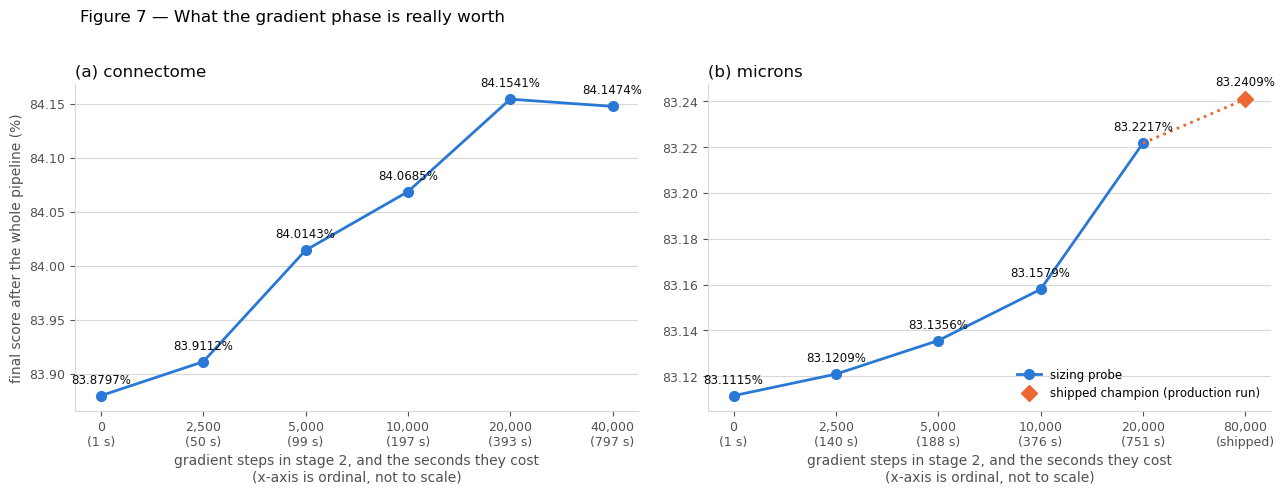

CONNECTOME
  no gradient phase at all : 83.87975 %   (stage 2 costs 0.7 s)
  shipped 20,000 steps     : 84.15410 %   (stage 2 costs 393 s)
  => the whole GPU phase is worth +0.27435 pp, not the +14 pp it appears to add in the chain
  doubling it to 40,000    : 84.14743 %   (-0.00666 pp for +403 s)

MICRONS  (the champion runs 80,000 steps here)
  no gradient phase at all : 83.11152 %
  20,000 steps             : 83.22167 %   (751 s)
  80,000 steps (shipped)   : 83.24085 %
  => first 20,000 steps buy +0.11015 pp
  => last  60,000 steps buy +0.01919 pp for roughly 2272 more seconds

  cost of 0.001 pp in the microns gradient tail :  118.4 s
  cost of 0.001 pp in microns stage 4           :    2.3 s
  => the gradient tail is 52x the price per unit of score


In [10]:
"""Figure 7 — ablation: what the gradient phase is really worth."""
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

summary = {}
for panel, (ax, ds) in enumerate(zip(axes, ["connectome", "microns"])):
    grid = load_json(CONFIG["epoch_grid"][ds])
    arms = grid["arms"]
    ep = np.array([a["epochs"] for a in arms])
    final = np.array([a["final_pct"] for a in arms])
    t_rk = np.array([a["t_rocket_s"] for a in arms])

    ax.plot(np.arange(len(ep)), final, marker="o", markersize=7,
            color=CONFIG["stage_colors"][0], linewidth=2.0, label="sizing probe")
    for i, a in enumerate(arms):
        ax.annotate(f"{final[i]:.4f}%", (i, final[i]), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=8.5, color=CONFIG["ink"])

    ticks = [f"{e:,}\n({t:.0f} s)" for e, t in zip(ep, t_rk)]
    # The microns probe has no 80,000 arm, so the champion itself supplies that point.
    # It comes from a production run, not the probe, so it is drawn as a distinct mark.
    if ds == "microns":
        champ = load_json(CONFIG["trace"]["microns"])
        ax.plot([len(ep)], [champ["pct"]], marker="D", markersize=8, linestyle="none",
                color=CONFIG["stage_colors"][1], label="shipped champion (production run)")
        ax.plot([len(ep) - 1, len(ep)], [final[-1], champ["pct"]],
                color=CONFIG["stage_colors"][1], linewidth=2.0, linestyle=":")
        ax.annotate(f"{champ['pct']:.4f}%", (len(ep), champ["pct"]),
                    textcoords="offset points", xytext=(0, 10), ha="center",
                    fontsize=8.5, color=CONFIG["ink"])
        ticks.append("80,000\n(shipped)")
    ax.set_xticks(np.arange(len(ticks)))
    ax.set_xticklabels(ticks, fontsize=8.5)
    ax.set_xlabel("gradient steps in stage 2, and the seconds they cost\n"
                  "(x-axis is ordinal, not to scale)")
    ax.set_title(f"({'ab'[panel]}) {ds}", loc="left")
    ax.legend(loc="lower right", fontsize=8.5)
    style_axes(ax)

    summary[ds] = {"zero_pct": arms[0]["final_pct"], "arms": arms}

axes[0].set_ylabel("final score after the whole pipeline (%)")
axes[0].get_legend().remove()          # panel (a) has a single series; the title names it
fig.suptitle("Figure 7 — What the gradient phase is really worth",
             x=0.065, ha="left", fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, "champion_fig7_ablation.png")
plt.show()

# ── The numbers behind the picture
c = summary["connectome"]
c_zero = c["zero_pct"]
c_ship = next(a for a in c["arms"] if a["epochs"] == 20000)
print("CONNECTOME")
print(f"  no gradient phase at all : {c_zero:.5f} %   (stage 2 costs 0.7 s)")
print(f"  shipped 20,000 steps     : {c_ship['final_pct']:.5f} %   "
      f"(stage 2 costs {c_ship['t_rocket_s']:.0f} s)")
print(f"  => the whole GPU phase is worth +{c_ship['final_pct'] - c_zero:.5f} pp, "
      f"not the +14 pp it appears to add in the chain")
c_40k = next((a for a in c["arms"] if a["epochs"] == 40000), None)
if c_40k:
    print(f"  doubling it to 40,000    : {c_40k['final_pct']:.5f} %   "
          f"({c_40k['final_pct'] - c_ship['final_pct']:+.5f} pp for "
          f"{c_40k['t_rocket_s'] - c_ship['t_rocket_s']:+.0f} s)")

m = summary["microns"]
m_arms = m["arms"]
m_zero = m_arms[0]["final_pct"]
m_20k = next(a for a in m_arms if a["epochs"] == 20000)
m_champ_pct = load_json(CONFIG["trace"]["microns"])["pct"]
print("\nMICRONS  (the champion runs 80,000 steps here)")
print(f"  no gradient phase at all : {m_zero:.5f} %")
print(f"  20,000 steps             : {m_20k['final_pct']:.5f} %   "
      f"({m_20k['t_rocket_s']:.0f} s)")
print(f"  80,000 steps (shipped)   : {m_champ_pct:.5f} %")
m_champ = load_json(CONFIG["trace"]["microns"])
m_attrs = m_champ["variant_attrs"]
m_stage12 = (m_champ["runtime_guard"]["variant_wall_s"] - m_attrs["sift_time_s"]
             - m_attrs["alt_time_s"] - m_attrs["pair_time_s"])
m_tail_s = m_stage12 - m_20k["t_rocket_s"]
m_tail_pp = m_champ_pct - m_20k["final_pct"]
print(f"  => first 20,000 steps buy +{m_20k['final_pct'] - m_zero:.5f} pp")
print(f"  => last  60,000 steps buy +{m_tail_pp:.5f} pp for roughly {m_tail_s:.0f} "
      "more seconds")

# Put the worst second and the best second on the same scale, from this run's numbers.
tail_cost = m_tail_s / (m_tail_pp * 1000)                       # s per 0.001 pp
alt_gain_pp = m_attrs["alt_best_pct"] - m_attrs["sift_best_pct"]
alt_cost = m_attrs["alt_time_s"] / (alt_gain_pp * 1000)         # s per 0.001 pp
print(f"\n  cost of 0.001 pp in the microns gradient tail : {tail_cost:6.1f} s")
print(f"  cost of 0.001 pp in microns stage 4           : {alt_cost:6.1f} s")
print(f"  => the gradient tail is {tail_cost / alt_cost:.0f}x the price per unit of score")

### What figure 7 says

**On the fly connectome:** the entire ~390-second GPU phase is worth **at most
+0.27 pp** to the final answer — not the +14 pp it appears to contribute in the
chain. The discrete stages recover almost everything it found.

*"At most"* is the important word. Stage 3 was cut off at its 40-sweep limit in
**every** arm of this probe, and the gradient-free arm — starting from a much worse
ordering — is the one with the most left to recover when it is cut off. So the true
value of the gradient phase sits somewhere between 0 and 0.27 pp; this experiment
bounds it from above rather than measuring it.

Doubling the phase to 40,000 steps then makes the final answer *slightly worse*,
despite making its own intermediate output better.

**On microns:** stages 1–2 eat **95%** of a 54-minute run, and almost all of that is
the gradient phase. The first 20,000 steps buy +0.110 pp; the remaining 60,000 steps
buy **+0.019 pp** for about 2,300 extra seconds — roughly **120 seconds per
0.001 pp**. The cell above prices the same 0.001 pp inside stage 4 on the same
dataset: the gradient tail is about **50× more expensive** per unit of score.

**The non-obvious part.** A better intermediate ordering does not *guarantee* a
better final one. Between 20,000 and 40,000 connectome steps the score after stage 2
rises 0.136 pp, after stage 3 rises 0.033 pp, and the final score **falls**
0.007 pp.

Scope this correctly: that is **one** inversion, at one pair of settings, on one
graph, and it is small — a quarter of the noise threshold the project uses elsewhere.
But the pipeline is deterministic, so it is a genuine counter-example rather than a
fluctuation. It is enough to say the pipeline is *not guaranteed* monotone in the
quality of its input; it is **not** enough to say improvements generally fail to
transfer. The practical rule is the same either way: measure a stage change end to
end, never in isolation.

*(Two caveats on the timings in this section. First, the sizing artifacts record
that the machine was not always idle when they ran — the **scores** are
deterministic and unaffected, the **seconds** are indicative. Second, the
zero-gradient arm's stage 3 ran all 40 of its allowed sweeps, i.e. it stopped on its
limit rather than because it had finished, which is why 83.880% is a lower bound and
+0.27 pp is an upper one.)*

---

## 9. The same five stages on all three datasets — but not the same settings

A result on one graph is an anecdote, so here are all three. **The stages are the
same; their budgets are not.** Each dataset gets its own, and the differences are
large enough that the panels must not be read as a like-for-like comparison:

| setting | connectome | microns | mouse |
|---|---|---|---|
| gradient steps (stage 2) | 20,000 | 80,000 | **0 — switched off** |
| sift sweeps (stage 3) | 40 | 12 | 40 |
| alternation cycles (stage 4) | 77 | 5 | 32 |
| pair moves (stage 5) | on | **off** | on |

The mouse column is the one to keep in mind below: with the gradient phase deleted,
its stage 3 starts from the raw greedy ordering and therefore absorbs work that
stage 2 does on the other two graphs. That is why its stage-3 bar is an order of
magnitude taller — not because the sift is better there.

dataset      stages 1-2   +stage 3   +stage 4   +stage 5       final      wall
------------------------------------------------------------------------------
connectome     82.9297%   +0.9838   +0.2406   +0.0209    84.1750%   1818.7s
microns        83.1281%   +0.0755   +0.0373   +0.0000    83.2409%   3225.9s
mouse          90.1263%   +2.9566   +0.0000   +0.0199    93.1028%      0.8s

time split (seconds):
dataset      stages 1-2   stage 3   stage 4   stage 5
connectome       420.6s    121.3s    630.3s    646.4s
microns         3056.6s     84.1s     85.3s      0.0s
mouse              0.7s      0.0s      0.0s      0.0s


saved: notebooks/outputs/champion_fig8_three_datasets.png


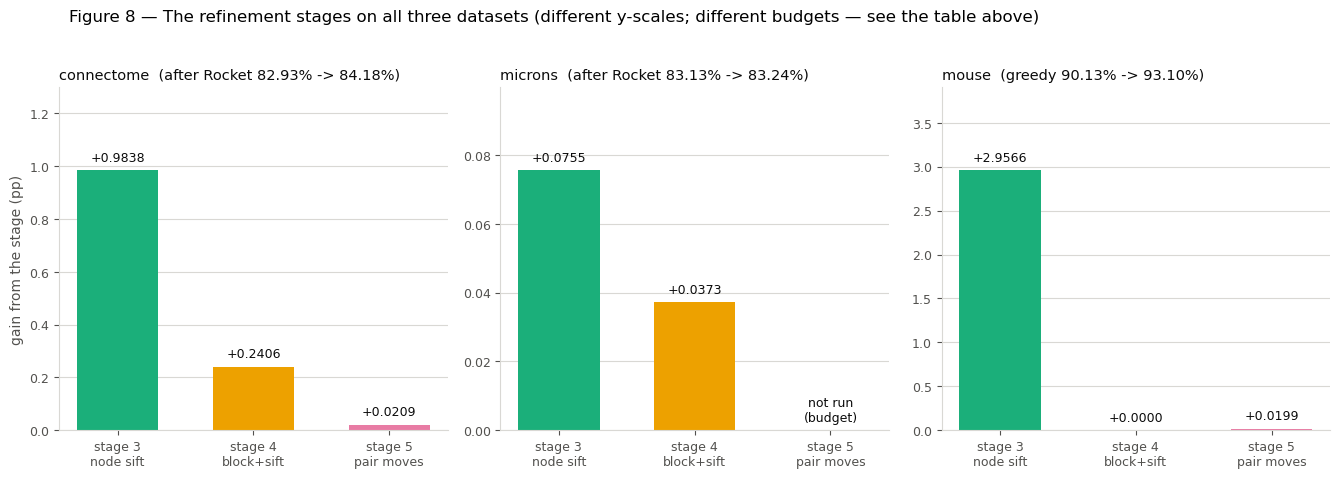

In [11]:
"""Figure 8 — stage contributions across the three datasets."""
DATASETS = ["connectome", "microns", "mouse"]
table, traces = [], {}

for ds in DATASETS:
    r = load_json(CONFIG["trace"][ds])
    a = r["variant_attrs"]
    traces[ds] = (r, a)
    t_stage12 = r["wall_clock_s"] - a["sift_time_s"] - a["alt_time_s"] - a["pair_time_s"]
    table.append({
        "dataset": ds,
        "start_pct": a["pure_best_pct"],
        "sift": a["sift_best_pct"] - a["pure_best_pct"],
        "alt": a["alt_best_pct"] - a["sift_best_pct"],
        "pair": a["pair_best_pct"] - a["alt_best_pct"],
        "final_pct": r["pct"],
        "t12": t_stage12, "t3": a["sift_time_s"],
        "t4": a["alt_time_s"], "t5": a["pair_time_s"],
        "total_s": r["wall_clock_s"],
        "epochs": r["total_grad_steps"],
    })

hdr = (f"{'dataset':11s} {'stages 1-2':>11s} {'+stage 3':>10s} {'+stage 4':>10s} "
       f"{'+stage 5':>10s} {'final':>11s} {'wall':>9s}")
print(hdr); print("-" * len(hdr))
for t in table:
    print(f"{t['dataset']:11s} {t['start_pct']:10.4f}% {t['sift']:+9.4f} {t['alt']:+9.4f} "
          f"{t['pair']:+9.4f} {t['final_pct']:10.4f}% {t['total_s']:8.1f}s")
print()
print("time split (seconds):")
print(f"{'dataset':11s} {'stages 1-2':>11s} {'stage 3':>9s} {'stage 4':>9s} {'stage 5':>9s}")
for t in table:
    print(f"{t['dataset']:11s} {t['t12']:10.1f}s {t['t3']:8.1f}s {t['t4']:8.1f}s "
          f"{t['t5']:8.1f}s")

DISABLED = {("microns", "stage 5\npair moves")}   # _PAIR_MAX_POPS["microns"] = 0

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, t in zip(axes, table):
    contrib = [t["sift"], t["alt"], t["pair"]]
    labels = ["stage 3\nnode sift", "stage 4\nblock+sift", "stage 5\npair moves"]
    colors = CONFIG["stage_colors"][2:5]
    ax.bar(range(3), contrib, color=colors, width=0.6)
    for i, v in enumerate(contrib):
        note = ("not run\n(budget)" if (t["dataset"], labels[i]) in DISABLED
                else f"+{v:.4f}")
        ax.text(i, max(contrib) * 0.035 + v, note, ha="center", fontsize=9,
                color=CONFIG["ink"])
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, max(contrib) * 1.32 if max(contrib) > 0 else 1)
    started = "greedy" if t["epochs"] == 0 else "after Rocket"
    ax.set_title(f"{t['dataset']}  ({started} {t['start_pct']:.2f}% "
                 f"-> {t['final_pct']:.2f}%)", loc="left", fontsize=10.5)
    style_axes(ax)
axes[0].set_ylabel("gain from the stage (pp)")
fig.suptitle("Figure 8 — The refinement stages on all three datasets "
             "(different y-scales; different budgets — see the table above)",
             x=0.055, ha="left", fontsize=12, y=1.03)
fig.tight_layout()
save_fig(fig, "champion_fig8_three_datasets.png")
plt.show()

### Reading figure 8 — and three honest footnotes

**The ordering of the stages holds everywhere**: the single-node sift does the bulk
of the work, the block stage adds a smaller amount, the pair stage smaller still.

**The magnitudes do not transfer.** On the two graphs that run the same stage-2
setup, the fly connectome leaves ~13× more on the table for the sift than microns
does. This is a property of the graphs, not of the method, and it is why the project
always reports per-dataset numbers rather than an average.

**Footnote 1 — mouse's stage-3 bar is not comparable to the other two.** With the
gradient phase switched off there, stage 3 starts from the greedy ordering at 90.1%
and does stage 2's job as well as its own.

**Footnote 2 — `mouse` is a supporting dataset, not a result.** It has 148 nodes and
is essentially saturated: stage 4 changes nothing at all, and stage 5 changes it by
a single move. It is kept as a tripwire — a variant that breaks on mouse is broken —
not as evidence of a gain.

**Footnote 3 — stage 5 is switched off on microns.** Not because it fails: with it
enabled microns reaches 83.24329% (+0.0024 pp). It is off because that run took
**3,435 s** against a hard 3,450-second deadline. A budget decision, recorded as one.

In [12]:
"""The microns stage-5 story, from the two run records."""
off = load_json(CONFIG["trace"]["microns"])
on = load_json(CONFIG["microns_stage5_on"])
print(f"microns, stage 5 OFF : {off['pct']:.5f} %   wall {off['wall_clock_s']:8.1f} s")
print(f"microns, stage 5 ON  : {on['pct']:.5f} %   wall {on['wall_clock_s']:8.1f} s")
print(f"  gain from stage 5  : {on['pct'] - off['pct']:+.5f} pp "
      f"for {on['variant_attrs']['pair_time_s']:.0f} s")
print(f"  runtime deadline   : {on['runtime_guard']['time_limit_s']:.0f} s "
      f"-> only {on['runtime_guard']['time_limit_s'] - on['wall_clock_s']:.0f} s of margin left")

microns, stage 5 OFF : 83.24085 %   wall   3225.9 s
microns, stage 5 ON  : 83.24329 %   wall   3435.5 s
  gain from stage 5  : +0.00243 pp for 220 s
  runtime deadline   : 3450 s -> only 14 s of margin left


---

## 10. How the project got here

Each row below is one step in the project's history. Two things to read carefully:
the last row (H52) was **measured but refused promotion** — section 11 is about
exactly that; and the `n` and `role` columns say how much evidence each number rests
on, which is not the same for every row (H35 is a single `verify` run, not a
confirmed five-seed pool).

variant                what changed                    score   n      role     device        step
-------------------------------------------------------------------------------------------------
baseline_passthrough   Rocket from a random start   82.8790%  15   confirm  Apple MPS            
H02                    + greedy warm start          82.9297%  15   confirm  Apple MPS  +0.0508 pp
H30                    + node sift                  83.7761%   5   confirm  Apple MPS  +0.8463 pp
H35                    + under-relaxation           83.9135%   1    verify   RTX 4060  +0.1375 pp
H36                    + SCC block moves            84.0972%   5   confirm   RTX 4060  +0.1837 pp
H42                    + re-allocated budget        84.1541%   5   confirm   RTX 4060  +0.0569 pp
H52                    + pair moves (not promoted)   84.1750%   5   confirm   RTX 4060  +0.0209 pp

The 'step' column is indicative only. Each variant's CONFIRMED effect was
measured against its own matched comparato

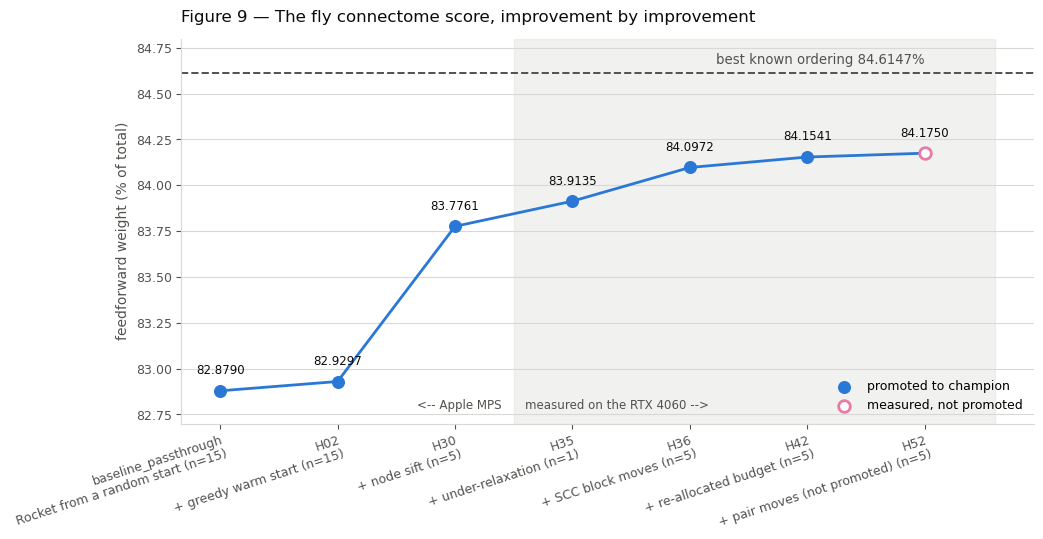

In [13]:
"""Figure 9 — the history of the connectome score."""
import collections
import glob

# Aggregate every logged connectome run by (variant, role, device).
buckets = collections.defaultdict(list)
for path in glob.glob(str(ROOT / "results" / "*.json")):
    try:
        d = json.loads(pathlib.Path(path).read_text())
    except Exception:
        continue
    if d.get("dataset") != "connectome" or "algo" not in d or d.get("role") is None:
        continue
    gpu = str((d.get("env") or {}).get("gpu", ""))
    device = "RTX 4060" if "RTX" in gpu else "Apple MPS"
    buckets[(d["algo"], d["role"], device)].append(d["pct"])

ROLE_PREFERENCE = ["confirm", "verify", "implement"]


def best_record(variant):
    """Strongest evidence pool for a variant.

    Role comes FIRST, not pool size. A `confirm` pool is a single homogeneous
    configuration, whereas pooling roles can silently mix two configurations of the
    same variant id (H30 was run at two different sweep caps under one id, and the
    config hash does not distinguish them). Device and pool size break ties.
    """
    options = [(role, dev, v) for (a, role, dev), v in buckets.items() if a == variant]
    if not options:
        return None
    options.sort(key=lambda o: (ROLE_PREFERENCE.index(o[0]), o[1] != "RTX 4060", -len(o[2])))
    role, dev, vals = options[0]
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)),
            "n": len(vals), "role": role, "device": dev}


history = []
for variant, label in CONFIG["history"]:
    rec = best_record(variant)
    if rec:
        history.append({"variant": variant, "label": label, **rec})

hdr = (f"{'variant':22s} {'what changed':26s} {'score':>10s} {'n':>3s} {'role':>9s} "
       f"{'device':>10s} {'step':>11s}")
print(hdr); print("-" * len(hdr))
prev = None
for h in history:
    delta = "" if prev is None else f"{h['mean'] - prev:+.4f} pp"
    print(f"{h['variant']:22s} {h['label']:26s} {h['mean']:9.4f}% {h['n']:3d} "
          f"{h['role']:>9s} {h['device']:>10s} {delta:>11s}")
    prev = h["mean"]
print("\nThe 'step' column is indicative only. Each variant's CONFIRMED effect was")
print("measured against its own matched comparator (same machine, same configuration);")
print("the differences above cross a change of machine and, at H30, a change of setting.")
promoted = [h for h in history if h["variant"] != "H52"][-1]
print(f"\nbest known ordering:            {CONFIG['reference_pct']}%  "
      f"({CONFIG['reference_note']})")
print(f"gap from the reported champion: "
      f"{CONFIG['reference_pct'] - promoted['mean']:.4f} pp  ({promoted['variant']})")
print(f"gap from the best measured:     "
      f"{CONFIG['reference_pct'] - history[-1]['mean']:.4f} pp  ({history[-1]['variant']}, "
      f"not promoted -- see section 11)")

fig, ax = plt.subplots(figsize=(11.0, 5.0))
xs = np.arange(len(history))
ys = np.array([h["mean"] for h in history])
is_promoted = np.array([h["variant"] != "H52" for h in history])

ax.plot(xs, ys, color=CONFIG["stage_colors"][0], linewidth=2.0, zorder=2)
ax.scatter(xs[is_promoted], ys[is_promoted], s=70, color=CONFIG["stage_colors"][0],
           zorder=3, label="promoted to champion")
ax.scatter(xs[~is_promoted], ys[~is_promoted], s=70, facecolor="white", zorder=3,
           edgecolor=CONFIG["stage_colors"][4], linewidth=2.0,
           label="measured, not promoted")
ax.axhline(CONFIG["reference_pct"], color=CONFIG["ink_soft"], linestyle="--", linewidth=1.4)
ax.text(len(history) - 1, CONFIG["reference_pct"] + 0.045,
        f"best known ordering {CONFIG['reference_pct']}%",
        ha="right", fontsize=9.5, color=CONFIG["ink_soft"])

for x, h in zip(xs, history):
    ax.annotate(f"{h['mean']:.4f}", (x, h["mean"]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=8.5, color=CONFIG["ink"])

# Mark where the project changed machine: scores are not perfectly comparable across it.
switch = next(i for i, h in enumerate(history) if h["device"] == "RTX 4060")
ax.axvspan(switch - 0.5, len(history) - 0.4, color=CONFIG["grid"], alpha=0.35, zorder=0)
ax.text(switch - 0.4, 82.78, "measured on the RTX 4060 -->", fontsize=8.5,
        color=CONFIG["ink_soft"])
ax.text(switch - 0.6, 82.78, "<-- Apple MPS", fontsize=8.5, ha="right",
        color=CONFIG["ink_soft"])

ax.set_xticks(xs)
ax.set_xticklabels([f"{h['variant']}\n{h['label']} (n={h['n']})" for h in history],
                   fontsize=8.5, rotation=18, ha="right", rotation_mode="anchor")
ax.set_ylabel("feedforward weight (% of total)")
ax.set_ylim(82.7, 84.8)
ax.set_title("Figure 9 — The fly connectome score, improvement by improvement",
             loc="left", pad=12)
ax.legend(loc="lower right", fontsize=9)
style_axes(ax)
save_fig(fig, "champion_fig9_history.png")
plt.show()

**Two footnotes this chart needs.**

1. **The machine changed partway.** The first four points were measured on an Apple
   MPS laptop, the last three on an RTX 4060. Scores are not perfectly
   machine-independent: H35 measures 83.9101% on MPS and 83.9135% on CUDA. The
   difference (0.003 pp) is far smaller than any of the steps in the chart, but it
   is real and the campaign re-measured every champion after the move rather than
   comparing across machines.
2. **H30 appears at its confirmed configuration.** Its sift sweep limit was later
   raised, which lifts H30 itself to ~83.81% — and H35's improvement was measured
   against *that* higher figure, not against the number plotted here. (These runs
   predate the per-stage logging used elsewhere in this notebook, so the sweep count
   is not inside their records; it is documented in the project log.)

---

## 11. Why the best measured number is not the reported number

The best connectome score in this notebook is **84.17502%** (stage 5 included). The
number the project *reports* is **84.15410%** (stages 1–4).

This is deliberate, and it is worth showing a supervisor, because the reasoning is
the kind of thing that is easy to get wrong in the other direction.

**The situation.** The project applies *two* significance criteria, and for the first
time they disagree:

| criterion | what it requires | stage 5 on connectome |
|---|---|---|
| minimum effect size | Δ > 0.012 pp | +0.02093 pp → **PASS** |
| protocol confidence bound | 95% CI lower bound > 0 | −0.0025 → **FAIL** |

The second one is the obstacle. It computes the confidence bound with the standard
deviation **floored** at a historical value — 0.0189 pp, the seed-to-seed noise of
the old *random-initialisation* baseline. With that floor, a five-seed comparison
must exceed **0.02343 pp** to promote. We have 0.02093 pp: real, five seeds,
standard deviation exactly 0, gain arithmetic verified against the frozen scorer to
twelve decimal places.

**The temptation, and why it was refused.** The threshold shrinks as $\sqrt{2/n}$,
so at seven seeds it drops to 0.0198 pp and the same result passes — without a
single new measurement of anything. (Strictly, it is the *comparator's* seed count
that enters the formula, so it is the previous champion that would have to be
re-run.) On a pipeline whose measured spread is exactly zero, extra seeds carry
**no information**: they only shrink an artificial standard error until it admits
the answer you already have. That is precisely what the rule exists to prevent, so
it was not done.

**What was done instead.** The result is recorded as measured, the promotion is
withheld, and the disagreement is filed as an open question for a human to settle
(it is item **P09** in the project's queue, at top priority). Even fully converged
the move class yields +0.02233 pp, so no amount of tuning clears that floor — this
is a question about the rule, not about the algorithm.

**Our reading — and this paragraph is opinion, not a project decision.** The rule
looks mis-specified for this case: it imports a noise estimate from a *randomised*
algorithm and applies it to a *deterministic* one. The honest fix is to state a
different criterion for deterministic pipelines — a minimum effect size plus
reproducibility from a clean checkout — rather than to adjust $n$ until the existing
formula agrees. (This is close to one of the options already written into P09, so it
is a position the project has considered, not an outsider's suggestion.)

---

## 12. Summary

### The pipeline in one table

| # | stage | what it does | adds | costs | GPU? |
|---|---|---|---|---|---|
| 1 | Greedy peel | builds a first ordering from the wiring | → 68.91% | ~17 s | no |
| 2 | Rocket | smooths it with gradient descent | → 82.93% | ~394 s | **yes** |
| 3 | Node sift | moves one neuron at a time to its exact best slot | **+0.98 pp** | 121 s | no |
| 4 | SCC block + sift | reorders whole blocks, alternating with a short sift | +0.24 pp | 630 s | no |
| 5 | Pair moves | moves two neurons that only help together | +0.02 pp | 646 s | no |

Final: **84.154%** as reported (stages 1–4), **84.175%** as measured (stages 1–5).
Published reference: 84.615%.

### Five things this run shows

1. **The discrete stages do the work.** Stages 3–5 add ~1.25 pp with **zero**
   gradient steps and no GPU. Separately — and on a different basis, so do not
   subtract one from the other — *deleting* the gradient phase costs only ~0.27 pp
   (section 8). The first figure is what stages 3–5 add where they sit in the chain;
   the second is what stage 2 is worth when you take it away.

2. **The cheapest stage is the most productive.** Stage 3 takes under 7% of the run
   and produces 4× more than stage 4, which takes 35% of it. Per minute, stage 3 is
   ~250× more efficient than stage 5.

3. **Returns are collapsing.** The last three measured improvements were worth
   +0.184, +0.057 and +0.021 pp — each roughly a third of the one before, while the
   seconds they cost went up. (The third of those, stage 5, was measured but not
   promoted — section 11.) There is no cheap score left on any axis that has been
   measured.

4. **How moves are applied may matter as much as which moves they are.** Applying
   wide moves one at a time, rather than in non-overlapping batches, was worth
   ~11.5× on the same move class — and two independent probe pairs agree on that
   factor. Neither pair separates "one at a time" from "more rounds", so this is the
   clearest open *direction*, not a settled result. The project's segment refiner
   uses disjoint batching and is the obvious place to test it.

5. **A better intermediate result is not a better final result.** More gradient
   steps improved every intermediate score and made the final score worse. Stages
   cannot be tuned in isolation.

### What is deliberately not claimed

* **Not that batching is the *cause* of the ~11.5×.** In one comparison the batched
  arm got one round and the sequential arm six; in the other both iterated but to
  different budgets. "One at a time" and "more rounds" are not separated.
* **Not that +0.27 pp measures the gradient phase.** It is an upper bound: every arm
  of that probe had its stage 3 truncated, and the gradient-free arm had the most
  left to recover.
* **Not that the pipeline is the same across datasets.** Mouse runs zero gradient
  steps, microns has stage 5 disabled, and the sweep and cycle caps differ
  (section 9).
* **Not that the stage-1 and stage-2 seconds come from this run.** They are prorated
  from a separate sizing probe; only their sum (401.9 s) is this run's own.
* **Not that five seeds show robustness.** The algorithm ignores its seed by
  construction, so those five runs are five repetitions of one computation. They
  show the machine reproduces itself, nothing more.
* Not that stage 5 is a confirmed improvement on the connectome — measured, not
  promoted (section 11).
* Not that the magnitudes transfer between graphs — they do not (section 9).
* Not that 84.615% is a ceiling, nor that we know how it was produced. It is the best
  submission on file for this graph, used purely as a yardstick; its method could not be
  retrieved, and it is **not** the 84.6125% reported in Vahidi 2025.
* Not that mouse results are evidence — that dataset is a tripwire, not a primary.

### Reproducing this notebook

It reads only committed artifacts, so from a clean checkout of this branch:

```bash
python notebooks/create_champion_walkthrough.py     # regenerate the notebook
jupyter nbconvert --to notebook --execute \
    notebooks/champion_pipeline_walkthrough.ipynb   # run it (seconds, CPU only)
```

The underlying runs themselves are reproduced with
`bash autoresearch/sweep.sh --exp H52 --role confirm --auto-seeds` on a machine
with the recorded GPU — about 30 minutes per connectome seed.